# Per iniziare
Prima di addentrarci nell'argomento, assicuriamoci che tutti gli aspetti tecnici funzionino come previsto. È necessario che `python` sia installato correttamente e che siano presenti anche le librerie `qiskit`, `numpy` e `matplotlib`.

Per poter eseguire il codice, dobbiamo innanzitutto assicurarci di disporre di un'installazione di Python con tutti i requisiti necessari per il codice di questo corso.

Quando si lavora con Python, si consiglia di utilizzare una distribuzione Python come `miniconda` per gestire l'installazione dei diversi pacchetti. Con `miniconda` è possibile creare “ambienti” Python separati, che possono avere tutti una versione diversa di Python e diversi pacchetti installati, ciascuno dei quali può essere di versioni separate. Ciò evita il problema comune dei conflitti tra le versioni dei pacchetti se si lavora su più progetti diversi con Python.

Per installare `miniconda`, scarica il programma di installazione corretto da [https://docs.conda.io/projects/miniconda/en/latest/]() e segui le istruzioni in fondo alla pagina. Su Linux e MacOS puoi anche semplicemente eseguire il file nel terminale:

```> sh Miniconda3-latest-Linux-x86_64.sh```

e seguire le istruzioni del programma di installazione.

Una volta installato `miniconda`, puoi riavviare il terminale: dovresti vedere `(base)` sul lato sinistro della finestra. Ciò indica che l'environment `miniconda` attualmente attivo è `base`.

Per installare tutti i requisiti necessari per questo corso, abbiamo preparato un file [`requirements.yml`](https://qplaylearn.github.io/oqs-jupyterbook/requirements.yml) che puoi utilizzare per creare un environment. Per creare un nuovo environment `miniconda` con tutti i requisiti, esegui:

```> conda env create -f requirements.yaml```

Questo dovrebbe creare un nuovo environment con il nome `oqs-digiq`. Per attivarlo, esegui:

```> conda activate oqs-digiq```

Dovrai farlo ogni volta che riavvii il terminale e desideri passare a questo ambiente. Se ora vedi `(oqs-digiq)` sul lato sinistro del terminale, puoi procedere!

Puoi utilizzare qualsiasi editor di testo con cui ti trovi a tuo agio (io uso [Visual Studio Code](https://code.visualstudio.com/)), ma ti preghiamo di consegnare le soluzioni degli esercizi in formato Jupyter Notebook o come file Python (`.py`). Si prega inoltre di commentare il codice dove lo si ritiene necessario e, nel caso in cui si invii un file Python, di descrivere come eseguire lo script e dove trovare i risultati sotto forma di commenti nel codice o in un file di testo o PDF separato. 

Un ottimo punto di partenza per familiarizzare con i concetti relativi ai sistemi quantistici aperti e all'informatica quantistica è il [capitolo “Preliminaries”](https://matteoacrossi.github.io/oqs-jupyterbook/preliminaries.html) tratto dal libro originale [Open Quantum Systems with Qiskit](https://matteoacrossi.github.io/oqs-jupyterbook/index.html).

Diamo innanzitutto un'occhiata a `numpy` ([Riferimento API](https://numpy.org/doc/1.23/reference/index.html)). Si tratta di una libreria Python molto utile che può essere impiegata per ogni tipo di calcolo numerico, in particolare per quanto riguarda matrici e array.

Python supporta naturalmente le liste (`list`) che hanno una dimensione dinamica, il che significa che è possibile aggiungere o rimuovere elementi dalle liste dopo averle create. Gli array `numpy`, invece, hanno una dimensione fissa, il che significa che è necessario creare un nuovo array se si desidera modificarne le dimensioni. Questo è uno dei motivi per cui le operazioni `numpy` sono in genere più veloci, poiché l'implementazione sottostante è basata sul linguaggio C.

Facciamo un rapido confronto.

In [1]:
python_list = [0,0,0,0]

Quando aggiungi altre liste, queste si concatenano.

In [2]:
python_list + python_list

[0, 0, 0, 0, 0, 0, 0, 0]

La sottrazione fra liste non è supportata.

In [3]:
python_list - python_list

TypeError: unsupported operand type(s) for -: 'list' and 'list'

Puoi aggiungere element a una lista di Python.

In [4]:
python_list.append(1)
python_list

[0, 0, 0, 0, 1]

Le liste possono anche contenere diversi tipi di oggetti, come dizionari, elementi di qualunque classe Python o addirittura altre liste.

Potresti trovare utili anche questi strumenti di Python.

In [1]:
# List comprehension
print([i for i in range(2,10)])

# Dictionary
result = {"a": 10, "b": 5, "c": 2}
print(result["a"])
result.update({"a": 0, "d": 5})
print(result)

# Enumerate (index and value)
for i, value in enumerate([10,11,12,13]):
    print(f"Index {i}, value {value}")

[2, 3, 4, 5, 6, 7, 8, 9]
10
{'a': 0, 'b': 5, 'c': 2, 'd': 5}
Index 0, value 10
Index 1, value 11
Index 2, value 12
Index 3, value 13


In [6]:
import numpy as np

numpy_array = np.array([1,0,0,1])

L'addizione con `numpy` invece realizza l'addizione fra elementi dell'array (elemento per elemento). Stessa cosa per la sottrazione, la moltiplicazione e la divisione.

In [7]:
numpy_array + numpy_array

array([2, 0, 0, 2])

Moltiplicare due array in questo modo realizza la moltiplicazione elemento per elemento.

In [8]:
np.array([1, 2]) * np.array([5, 10])

array([ 5, 20])

Liste e array multidimensionali possono essere creati usando liste di liste (o array di array).

In [9]:
numpy_array = np.array([[1,0,0,1], [0,0,0,1], [0,1,0,1], [0,0,0,0]])
numpy_array

array([[1, 0, 0, 1],
       [0, 0, 0, 1],
       [0, 1, 0, 1],
       [0, 0, 0, 0]])

Con gli array multidimensionali puoi tranquillamente applicare l'algebra lineare.

In [2]:
# Prodotto di matrici
print(numpy_array @ numpy_array)
print(numpy_array * numpy_array)

# Norma di una matrice
print(np.linalg.norm(numpy_array, ord=2))
print(np.trace(numpy_array))

# Coniugata trasposta di una matrice
complex_array = np.array([[1-1j, 0-1j], [0+0j, 1+1j]])
print(complex_array)
print(complex_array.T.conj())

NameError: name 'numpy_array' is not defined

`numpy` ha molte caratteristiche utili.

In [3]:
# Matrice Identità
I = np.eye(5)
print(I)

# Matrice random 2x2 
rand_matrix = np.random.choice([0,1,2], size=10, p=[0.1, 0.5, 0.4])
print(rand_matrix)

# Ripeti matrice 2x2 
tiled_matrix = np.repeat([[0,1],[2,3]], repeats=5, axis=1)
print(tiled_matrix)

NameError: name 'np' is not defined

`numpy` contiene anche un generatore di numeri casuali. Per estrarre un numero fra `0` e `1` con distribuzione uniforme puoi fare così.

In [12]:
np.random.choice([0,1], size=20)

array([0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0])

`matplotlib` ([User Guide](https://matplotlib.org/stable/users/index)) è la libreria più usata in Python per i plot. Puoi usarla in molti modi ed è molto flessibile.

In [4]:
import matplotlib.pyplot as plt

# Genera 100 valori random tra 0 e 1.
x = range(100)
y = np.random.random(100)

plt.figure(figsize=(8,4))

# Plotta 100 valori random 
plt.plot(x, y, label="Random signal")

# Barre d'errore a 1 deviazione standard
error = np.std(y)
plt.fill_between(x, y - error, y + error, alpha=.3)

# Plotta la media di 100 valori
plt.axhline(np.mean(y), linestyle="--", color="black", label="Average")
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.legend()

NameError: name 'np' is not defined

Ora possiamo iniziare a dare un'occhiata a `qiskit` ([Documentation](https://docs.quantum-computing.ibm.com/)). La libreria `qiskit` comprende numerosi strumenti per l'informatica quantistica sviluppati principalmente da IBM. La libreria è diventata molto ampia e contiene ogni genere di funzionalità, come la possibilità di creare circuiti quantistici, calcolare i valori attesi per i sistemi di meccanica quantistica, simulare dispositivi quantistici soggetti a rumore e così via. Ai fini di questa introduzione ci concentreremo principalmente sugli aspetti necessari per il resto del corso, che comprenderà la creazione di circuiti quantistici, la loro esecuzione su simulatori o dispositivi reali e l'analisi dei risultati.

Non ci addentreremo troppo nella teoria dell'informatica quantistica, ma vediamo i concetti fondamentali.

Un computer quantistico è costituito da qubit, un sistema quantistico a due livelli. Nei dispositivi IBM sono realizzati utilizzando superconduttori, ma esistono anche altre forme di realizzazione dei qubit. Un qubit presenta le proprietà di un sistema quantistico, il che significa che può trovarsi in sovrapposizione, essere intrecciato con altri qubit e così via. In pratica è difficile isolare completamente un computer quantistico dal suo ambiente, il che significa che i qubit interagiranno in qualche modo con l'ambiente. Nell'informatica quantistica consideriamo queste interazioni come rumore o errori, poiché il computer quantistico inizia a comportarsi in un modo che non ci aspetteremmo o non vorremmo.

Nel quadro dell'informatica quantistica, utilizziamo un insieme di operatori o porte che possono essere applicati a uno o più qubit. Alcuni di quelli più comuni sono le matrici di Pauli (X, Y, Z) e la porta CNOT, che applica la matrice X di Pauli su un qubit in base allo stato di un altro. La porta CNOT rende due qubit entangled. Ne parleremo più approfonditamente durante il corso.

Creiamo per prima cosa un circuito quantistico dove applichiamo la matrice X di Pauli su tutti i qubit. In un circuito quantistico assumiamo che tutti i qubit siano inizializzati nello stato $|0\rangle$. L'azione di X di Pauli su questo stato è di passarlo nello stato $|1\rangle$.

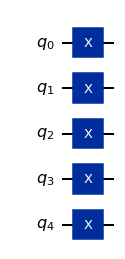

In [14]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(5)
qc.x([q for q in range(qc.num_qubits)])
qc.draw(output='mpl')

Possiamo osservare direttamente i vettori che rappresentano gli stati (statevector). Per chiarezza, facciamolo su un circuito a singolo qubit.

In [15]:
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
sv = Statevector(qc)
print(sv)

qc.x(0)
sv = Statevector(qc)
print(sv)

qc.h(0)
sv = Statevector(qc)
print(sv)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


Ora proviamo a eseguire un circuito su un simulatore. Abbiamo a disposizione diversi simulatori tra cui scegliere, compresi quelli che simulano modelli di rumore basati sul rumore effettivamente rilevato sui dispositivi quantistici reali di IBM. È persino possibile creare il proprio modello di rumore. Per il momento, però, supponiamo che il computer quantistico sia privo di rumore ed eseguiamo una simulazione ideale del circuito quantistico.

In [16]:
from qiskit_aer import AerProvider

AerProvider().backends()

[AerSimulator('aer_simulator'),
 AerSimulator('aer_simulator_statevector'),
 AerSimulator('aer_simulator_density_matrix'),
 AerSimulator('aer_simulator_stabilizer'),
 AerSimulator('aer_simulator_matrix_product_state'),
 AerSimulator('aer_simulator_extended_stabilizer'),
 AerSimulator('aer_simulator_unitary'),
 AerSimulator('aer_simulator_superop'),
 QasmSimulator('qasm_simulator'),
 StatevectorSimulator('statevector_simulator'),
 UnitarySimulator('unitary_simulator')]

Let us pick `aer_simulator`, which performs a noiseless statevector simulation, however simulates so-called shot noise. Shot noise arises due to the fact that 

Scegliamo `aer_simulator`, che esegue una simulazione del vettore di stato priva di rumore, ma simula il cosiddetto rumore a impulso. Il rumore a impulso nasce dal fatto che

In [17]:
backend = AerProvider().get_backend('aer_simulator')

Il simulatore pò anche esser creato direttamente così:

In [18]:
from qiskit_aer import AerSimulator

backend = AerSimulator()

Quando si creano circuiti, di solito è necessario tenere conto del layout hardware e della connettività dei qubit del dispositivo. Il simulatore, invece, offre una connettività completa (tutti i qubit possono eseguire un'operazione CNOT tra loro) e il limite del numero di qubit è spesso determinato dalla potenza del computer. Creiamo un semplice circuito quantistico a 5 qubit, con un po' di entanglement.

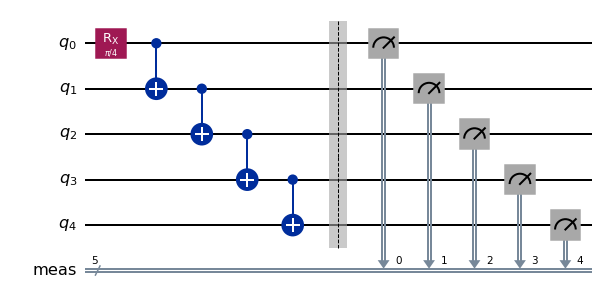

In [20]:
qc = QuantumCircuit(5)

qc.rx(np.pi/4, 0)

for target_qubit in range(1,5):
    qc.cx(target_qubit - 1, target_qubit)

# Salviamo il circuito senza la misurazione per usarlo dopo
qc_tmp = qc.copy()
qc.measure_all()
qc.draw(output='mpl')

Simuliamo ora il circuito con 1000 prove. Ciò significa che generiamo lo stato nel circuito quantistico e lo misuriamo 1000 volte. Ogni volta che effettuiamo una misurazione, in teoria possiamo ottenere un risultato diverso a seconda dello stato quantistico preparato. Questo esperimento ci fornisce un istogramma dei diversi risultati; pertanto, più prove effettuiamo, più accuratamente l'istogramma rappresenterà la distribuzione di probabilità prevista dello stato quantistico.

In [21]:
job = backend.run(qc, shots=10000)
result = job.result()
result.get_counts()

{'11111': 1463, '00000': 8537}

Possiamo calcolare le probabilità attese nel seguente modo:

In [22]:
# Costruire l'autovettore |00000> 
zero = np.array([1,0])
all_zeros_state = zero.copy()
for qubit in range(qc.num_qubits - 1):
    all_zeros_state = np.kron(all_zeros_state, zero)

psi = Statevector(qc_tmp)
psi_zero = Statevector(all_zeros_state)

# Calculare |<00000|psi>|^2
np.abs(psi.inner(psi_zero))**2

0.8535533905932737

In [24]:
all_zeros_state

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [23]:
# Costruire l'autovettore |11111> 

one = np.array([0,1])
all_ones_state = one.copy()
for qubit in range(qc.num_qubits - 1):
    all_ones_state = np.kron(all_ones_state, one)

psi = Statevector(qc_tmp)
psi_one = Statevector(all_ones_state)

# Calcolare |<11111|psi>|^2
np.abs(psi.inner(psi_one))**2

0.14644660940672624

In [25]:
psi

Statevector([0.92387953+0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ,
             0.        +0.j        , 0.        -0.38268343j],
            dims=(2, 2,

Proviamo lo stesso esperimento su un simulatore con rumore. Vengono usati modelli di rumore basati su dati di calibrazione di veri dispositivi quantistici IBM. Non sono perfettamente accurati ma fanno il loro mestiere.

In [26]:
from qiskit_ibm_runtime.fake_provider import FakeHanoi

backend = FakeHanoi()
job = backend.run(qc, shots=1000)
result = job.result()
result.get_counts()

{'01111': 2,
 '11110': 2,
 '00011': 1,
 '00001': 6,
 '00100': 16,
 '11011': 3,
 '11111': 128,
 '11100': 3,
 '10111': 3,
 '01000': 8,
 '00010': 9,
 '11101': 3,
 '10000': 11,
 '00000': 805}

Come puoi vedere, ora otteniamo molti risultati diversi, questo accade perché il rumore ha agito sui qubit!

Possiamo anche provare a far funzionare questi circuiti su un hardware reale. Per farlo, vai su [https://quantum-computing.ibm.com/]() e crea un account. Usa il token che ottieni dal sito web qui sotto per salvare il tuo account.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(token="TOKEN")

Per eseguire i circuiti seguiremo una procedura simile a quella descritta in precedenza, con alcune differenze. Si noti inoltre che ogni account ha a disposizione 10 minuti al mese per l'utilizzo di ciascun computer quantistico su IBM Quantum. Non ti chiederemo di condurre esperimenti su questi dispositivi, ma ti incoraggiamo a farlo se lo desideri!

In [ ]:
from qiskit_ibm_runtime import Sampler

service = QiskitRuntimeService()
service.backends()

In [ ]:
backend = service.get_backend("ibmq_qasm_simulator")
sampler = Sampler(backend)

job = sampler.run(qc, shots=1000)
job_id = job.job_id()
print(job_id)

Se desideri chiudere il portatile mentre aspetti in coda che il processo venga eseguito puoi salvare l'ID del processo. In questo modo sarà facile recuperare i risultati del processo in un secondo momento.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
job2 = service.job(job_id=job_id)
job2.result()

I risultati qui riportati non sono espressi in termini di conteggi, bensì come distribuzioni di quasi-probabilità. Ciò è dovuto al fatto che su questi risultati è possibile applicare alcune delle tecniche di mitigazione del rumore offerte da Qiskit. Tali tecniche possono restituire probabilità negative di entità minima e, in tal caso, non avrebbe senso riportare i conteggi.

In [ ]:
job2.result().quasi_dists